In [1]:
from geostat_isoscapes_tools import utils, geostat_utils, plot_utils
import numpy as np
from pykrige.uk import UniversalKriging
import json
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

#### KED computation for one time slice

The cell below is the workflow for our KED interpolation at one time slice. This automatized in script ```bin/kriging.py```.

> The workflow follows these steps :
> 1.  Define the parameters to use in the experiment (which variogram to use, path to the datasets...)
> 2.  Load SISAL (observations), iTraCE (external drift) and variogram data
> 3.  Compute the iTraCE field at SISAL observation points via a linear interpolation 
> 4.  Project all data (observation and external drift) in Mercator coordinate system, since kriging requires computing planar distances.
> 5.  Define the KED interpolator
> 6.  Interpolate
> 7.  Plot the resulting kriged maps and variance maps

converting speleothem data to drip-water equivalents...
sisal dataframe is ready
itrace_df ready


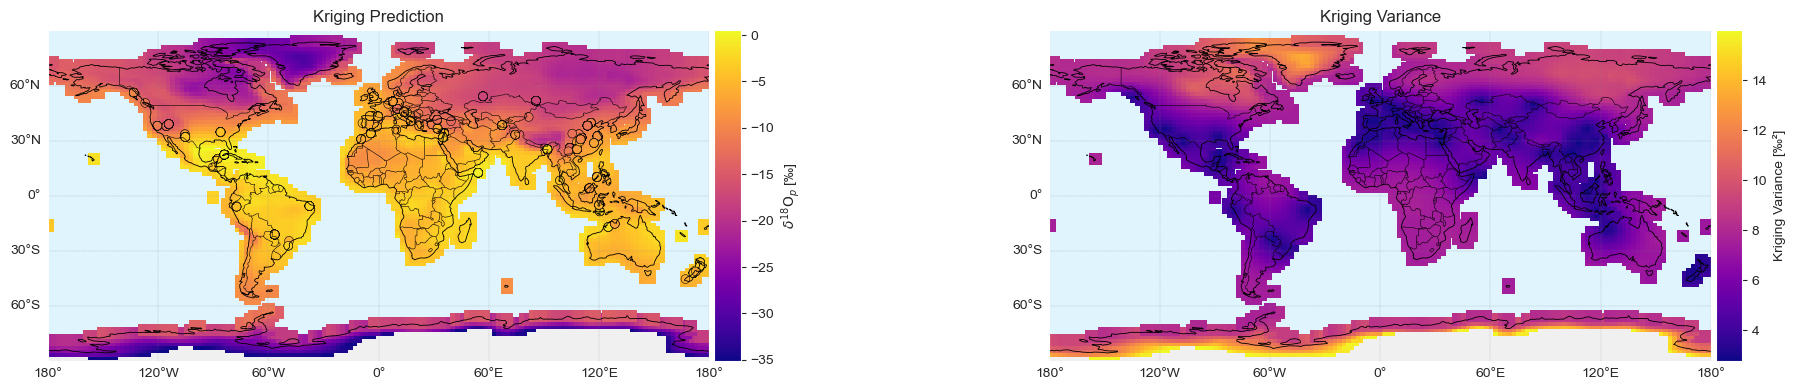

In [3]:
###### SETUP ######
qty='d18Op_VSMOW_linearized'
res_months=200*12
# vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json'
vario_path = '../output/variograms/2026-02-24_sisal_vs_itrace/itrace/sim12kyrBP/res2400/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/variogram_params_None.json'
temperature_ds_name = 'itrace' # 1) 'itrace' for 20-11 ka BP, or 2) 'krapp' for 0-800ka BP with res 1000 years
temperature_ds_path = '/media/luluxette/T7_Shield/pdm/iTrace/'

itrace_folder = '/media/luluxette/T7_Shield/pdm/iTrace/' # abs path to itrace data 

###### LOAD DATA ######
# SISAL 
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(
    res=res_months//12,
    temp_ds_name=temperature_ds_name,
    temp_ds_path=temperature_ds_path,
    conversion=qty,
    verbose=False
)

# ITRACE 
itrace_data = geostat_utils.get_preprocessed_itrace_data(data_folder=itrace_folder,res=res_months,verbose=False) # simulation 12k
itrace_times = itrace_data['time'].unique() #type:ignore # thisis the bumber of time steps in itrace df
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore
external_drift_df['lon'] = utils.convert_lon_0_360_to_neg180_180(np.asarray(external_drift_df['lon'].values))
# plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
# plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore
###### VARIOGRAM ######
with open(vario_path, 'r') as f:
    variogram_dict = json.load(f)
# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}
###### EXT DRIFT AT OBS POINTS ######
# Retrieve itrace **at** observation points
lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']
# Linear interpolation from itrace grid to observation points
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
obs_points = np.column_stack((lats_obs, lons_obs))
itrace_at_obs = griddata(grid_points, external_drift_df['d18Op'].values, obs_points, method='linear')
# fig,ax = plot_utils.plot_platecarree_field_and_scatter_on_top(external_drift_df,
#                                                               pd.DataFrame({'lat':lats_obs,'lon':lons_obs,'d18Op':itrace_at_obs}),
#                                                               )
# plt.show()
###### PROJECT IN MERCATOR COORDS ######
# Project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values
###### KRIGING ######
# universal kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs]
)
# execute 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)
# gather results in df
df_pred = pd.DataFrame({'lon': external_drift_df['lon'],
            'lat':external_drift_df['lat'],
            'z_pred':z_pred,
            'ss_pred':ss_pred})
# mask predictions according to a kriging variance threshold
df_pred_masked = df_pred[df_pred['ss_pred']<15]
###### PLOTTING ######
fig,axes = plot_utils.plot_ked_platecarree_points(
    df_pred=df_pred_masked,
    df_obs=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,4),
    adjust_extent=False
) # type:ignore
plt.tight_layout()
# plt.savefig('../output/ked_firsttests/test_fig.png',dpi=500)
plt.show()

#### Kriging validation metrics analysis 

In this section, we read and plot the cross-validation metrics obtained when running the script ```kriging.py```.

In [2]:
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
res_months = 12*200
list_crossval_df = []
list_crossval_metrics = [] 
for kyr in sims.keys() :
    for time in range((int(kyr)-1)*1000+res_months//12,int(kyr)*1000+1,res_months//12):
        fp_output = f"{utils.get_project_root()}/output/kriging/run_2026_03_05_all_varios/res{res_months}/plots_and_metrics/{str(int(time))}yrBP/"
        crossval_df = pd.read_csv(f'{fp_output}crossval_df.csv').reset_index(drop=True)
        crossval_df['time']=time
        with open(fp_output+'crossval_metrics.json', 'r') as f: 
            crossval_metrics = json.load(f)
        list_crossval_df.append(crossval_df)
        list_crossval_metrics.append(pd.DataFrame(crossval_metrics,index=[time]))

crossval_df = pd.concat(list_crossval_df)
crossval_metrics = pd.concat(list_crossval_metrics)

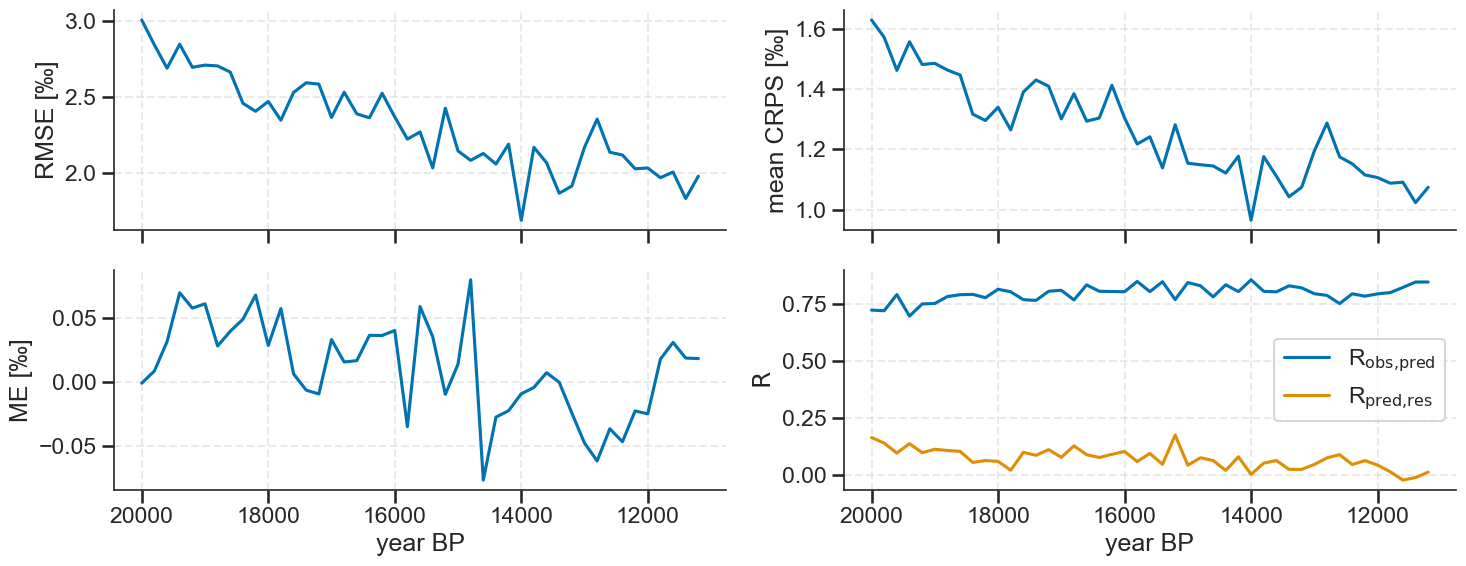

In [3]:
fig, axes = plt.subplots(2,2,figsize=(15,6),sharex='col')

# Scatter plot of irregular points
# axes[0].plot(crossval_metrics.index.values,crossval_metrics['MAE'])
axes[0,0].plot(crossval_metrics.index.values,crossval_metrics['RMSE'])
axes[0,0].set_ylabel('RMSE [‰]')
axes[1,0].plot(crossval_metrics.index.values,crossval_metrics['ME'])
axes[1,0].set_ylabel('ME [‰]')
axes[0,1].plot(crossval_metrics.index.values,crossval_metrics['mean CRPS'])
axes[0,1].set_ylabel('mean CRPS [‰]')
# rejected_slices = crossval_df.loc[crossval_df['|PES| > critical_val'],'time'].unique()
# axes[1,1].scatter(crossval_metrics[crossval_metrics.index.isin(rejected_slices)].index.values,np.ones(len(crossval_metrics[crossval_metrics.index.isin(rejected_slices)]))*0, marker='s', color='tab:orange',label=r'$H_0$ rejected')
# axes[1,1].scatter(crossval_metrics[~crossval_metrics.index.isin(rejected_slices)].index.values,np.ones(len(crossval_metrics[~crossval_metrics.index.isin(rejected_slices)]))*0, marker='s', color='darkcyan',label=r'$H_0$ not rejected')
# axes[1,1].plot(crossval_
# metrics.index.values,np.array([len(crossval_df[crossval_df.time==t]) for t in crossval_metrics.index.values]))
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_obs_pred'],label=r'R$_\text{obs,pred}$')
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_pred_res'],label=r'R$_\text{pred,res}$')
axes[1,1].set_ylabel(r'$\text{R}$')
axes[1,1].legend()
axes[1,1].set_xlabel('year BP')
axes[1,0].set_xlabel('year BP')
axes[0,0].grid(alpha=0.4)
axes[1,0].grid(alpha=0.4)
axes[0,1].grid(alpha=0.4)
axes[1,1].grid(alpha=0.4)
sns.despine(top=True,right=True)
axes[1,0].invert_xaxis()
axes[1,1].invert_xaxis()
plt.tight_layout()
# plt.savefig('../output/results_figs/KED_CV_metrics_over_time_agg_vario_noCriticalSites.png',dpi=500) #_noDevilsHole_noPacupahhuain
plt.show()

In [71]:
crossval_metrics['RMSE'].mean() #-crossval_metrics['mean CRPS'].min()

np.float64(2.172442364082564)

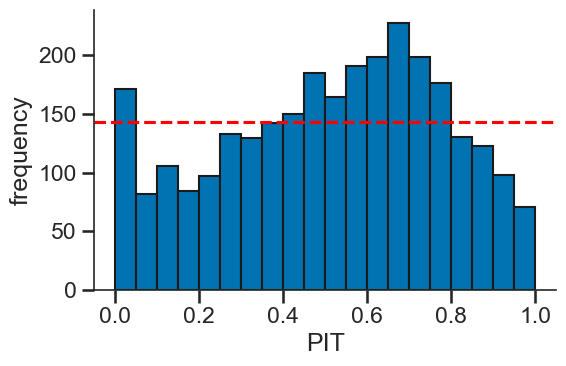

Skewness of PIT distribution: -0.2656494098298426


In [ ]:
import scipy.stats as stats

# PIT = Phi((z_obs – z_pred) / sigma) with sigma = sqrt(variance)
sigma = np.sqrt(crossval_df['ss_pred'].values)
pit_vals = stats.norm.cdf((crossval_df['z_obs'].values-crossval_df['z_pred'].values)/sigma)
# obs - pred : underestimation>0, overestimation<0
crossval_df['PIT'] = pit_vals
n=20
plt.figure(figsize=(6,4))
plt.hist(pit_vals[~np.isnan(pit_vals)], bins=n, edgecolor='k')
plt.axhline(len(pit_vals)/n, color='red', linestyle='--')
plt.xlabel('PIT')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout()
plt.savefig('../output/results_figs/PIT_histogram_agg_vario_noCriticalSites.png',dpi=500)
plt.show()

# compute skewness of PIT distribution
from scipy.stats import skew
skewness = skew(pit_vals[~np.isnan(pit_vals)])
print(f'Skewness of PIT distribution: {skewness}')
# we interpret a skewness value close to 0 as an indication of a well-calibrated model,
# while significant positive or negative skewness may suggest systematic biases in the predictions.
# In our case, a skewness of 0.26 suggests a slight bias towards underprediction (strong right tail),
# but it's not a strong deviation from 0, indicating that the model is reasonably well-calibrated.

In [14]:
crossval_df[crossval_df['PIT']<0.01]

,Unnamed: 0,site_name,lon,lat,z_pred,ss_pred,z_obs,drift_at_obs,dist_nn,residual,PES,|PES| > critical_val,ci,time,PIT
14,14,Devils Hole,-116.2915,36.4254,-11.053559,4.400193,-17.469812,-11.297182,174.634382,6.416254,-3.058762,False,6.839994,11200,0.001111
15,15,Devils Hole,-116.2915,36.4254,-10.990891,4.276028,-17.817538,-11.165134,174.634382,6.826647,-3.301317,True,6.695173,11600,0.000481
14,14,Devils Hole,-116.2915,36.4254,-12.408019,4.277024,-18.125392,-11.260857,174.634382,5.717372,-2.764558,False,6.709990,12000,0.002850
29,29,Hölloch im Mahdtal,10.1506,47.3781,-9.379664,4.562388,-14.420765,-11.591452,344.639810,5.041101,-2.360094,False,6.930221,12000,0.009135
26,26,Hölloch im Mahdtal,10.1506,47.3781,-9.551518,4.897243,-15.148955,-12.275184,346.343290,5.597437,-2.529376,False,7.149604,12200,0.005713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,37,Sieben Hengste cave,7.8100,46.7500,-9.448243,6.942428,-15.615415,-10.427182,561.429230,6.167172,-2.340617,False,8.076821,19800,0.009626
10,10,Devils Hole,-116.2915,36.4254,-13.710879,4.508353,-19.116182,-11.698114,87.226347,5.405303,-2.545722,False,6.573931,20000,0.005453
31,31,Pacupahuain cave,-75.8200,-11.2400,-8.971806,6.987578,-17.361342,-8.132593,612.441323,8.389537,-3.173764,True,8.184262,20000,0.000752
42,42,Sofular cave,31.9333,41.4167,-7.489673,7.589397,-14.890713,-8.142757,892.114046,7.401041,-2.686514,False,8.529427,20000,0.003610


In [76]:
crossval_df.PIT.median()

0.5252420671020246

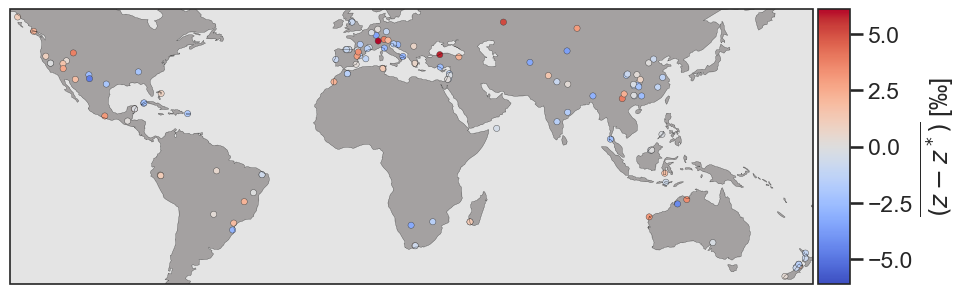

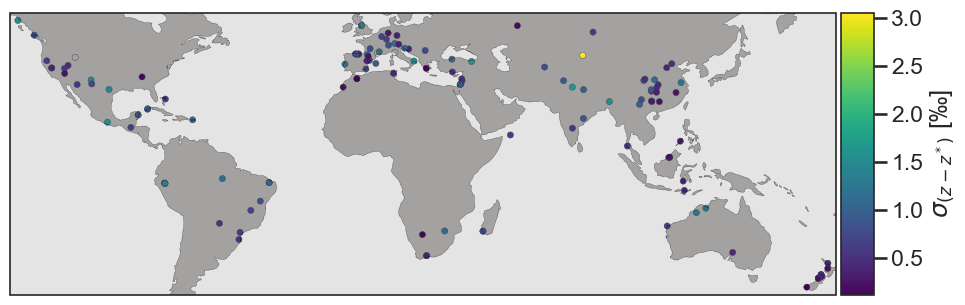

In [77]:
# map of metrics per site
def plot_metric_meanstd_per_site(crossval_df, qty_col,qty_label, cmap, cmap_sym0=False, unit='‰'):
    fig1,ax1= plot_utils.plot_isoscape_latlon_platecarree_df(
        df=crossval_df.groupby('site_name')[['lat','lon',qty_col]].mean().reset_index(),
        title=None,
        qty_col=qty_col,
        cmap=cmap,
        unit=unit,
        cmap_sym0=cmap_sym0,
        qty_label=rf'$\overline{{{qty_label}}}$'
        ) # type:ignore

    fig2,ax2= plot_utils.plot_isoscape_latlon_platecarree_df(
        df=crossval_df.groupby('site_name')[['lat','lon',qty_col]].agg({'lat':'first', 'lon':'first', qty_col:'std'}).reset_index(),
        qty_col=qty_col,
        title=None,
        unit=unit,
        qty_label=rf'$\sigma_{{{qty_label}}}$',
        cmap='viridis'  
        ) # type:ignore
    return (fig1,ax1),(fig2,ax2)

(fig1,ax1),(fig2,ax2) = plot_metric_meanstd_per_site(crossval_df,'residual','(z-z^*)','coolwarm',cmap_sym0=True,unit='‰') # type:ignore
plt.tight_layout()
plt.show()

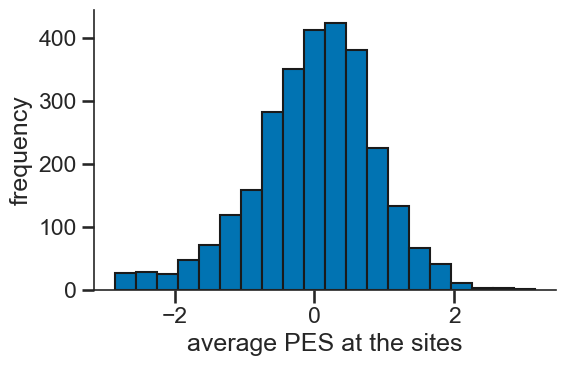

In [78]:
import scipy.stats as stats
# histogram of mean residuals per site 
plt.figure(figsize=(6,4))
plt.hist(crossval_df.PES.values, bins=20, edgecolor='k')
# plt.axhline(len(crossval_df.groupby('site_name')['PIT'].mean().values)/10, color='red', linestyle='--')
# overlay the normal distribution N(0,1)
# x = np.linspace(-3, 3, 100)
# y = stats.norm.pdf(x, loc=0, scale=0.6)
# plt.plot(x, y * len(crossval_df.groupby('site_name')) * 20 / 100, color='red', linewidth=2)
plt.xlabel('average PES at the sites')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout() 
plt.show()

In [79]:
crossval_df.loc[crossval_df.site_name == 'White Scar cave','PES'].values # no std of PES at this site since it appears only once in the time slices.

array([0.36773833])

In [80]:
crossval_df.columns

Index(['Unnamed: 0', 'site_name', 'lon', 'lat', 'z_pred', 'ss_pred', 'z_obs',
       'drift_at_obs', 'dist_nn', 'residual', 'PES', '|PES| > critical_val',
       'ci', 'time', 'PIT'],
      dtype='object')

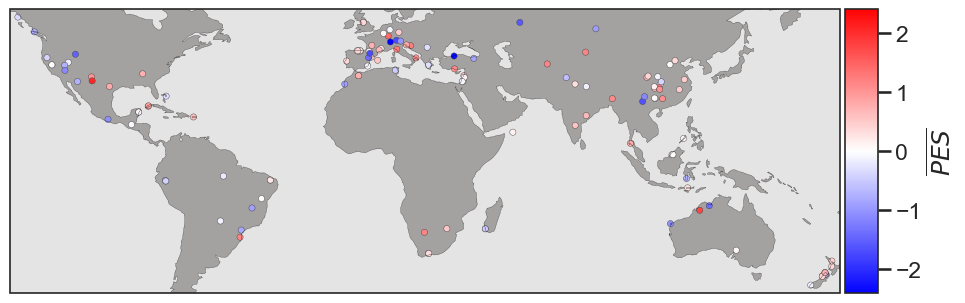

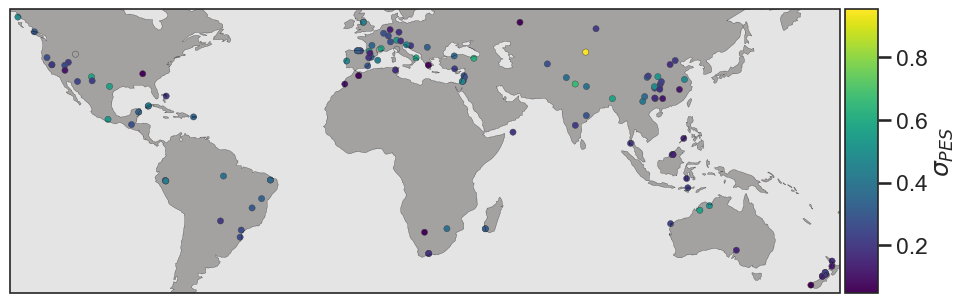

In [81]:
(fig1,ax1),(fig2,ax2) = plot_metric_meanstd_per_site(crossval_df,'PES','PES','bwr',cmap_sym0=True,unit=None) # type:ignore
plt.tight_layout()
plt.show()

In [82]:
df_site = crossval_df.loc[crossval_df.site_name=='Sieben Hengste cave']
df_site.PES.describe()

count    27.000000
mean     -2.403574
std       0.264362
min      -2.824980
25%      -2.611761
50%      -2.394527
75%      -2.191320
max      -1.784680
Name: PES, dtype: float64

Let us observe the cross-val predictions at some caves versus the observed values, over the whole period.

      site_name       lon      lat      PES
27  Devils Hole -116.2915  36.4254 -2.94386


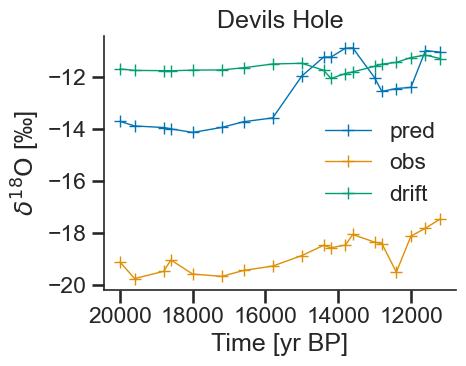

            site_name    lon   lat      PES
97  Pink Panther cave -105.2  32.0  2.11929


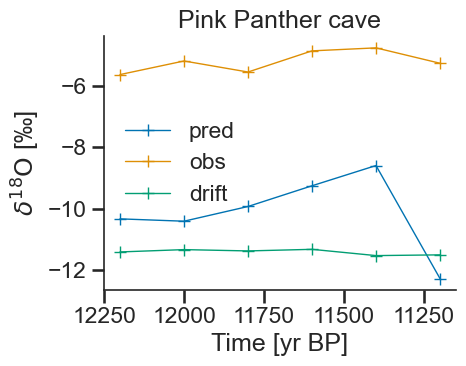

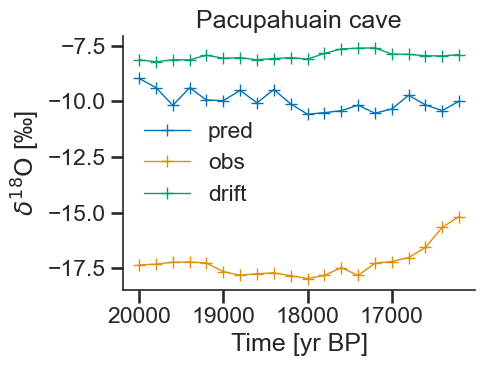

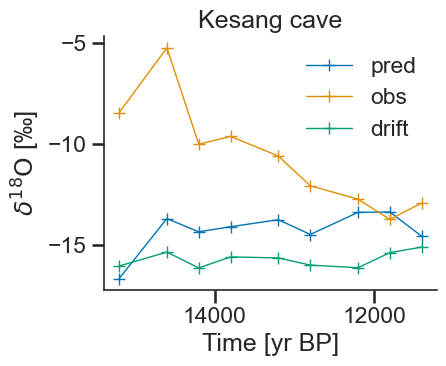

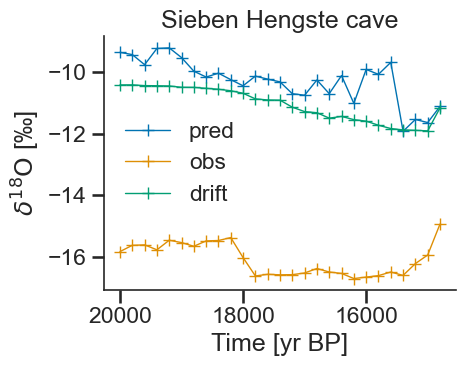

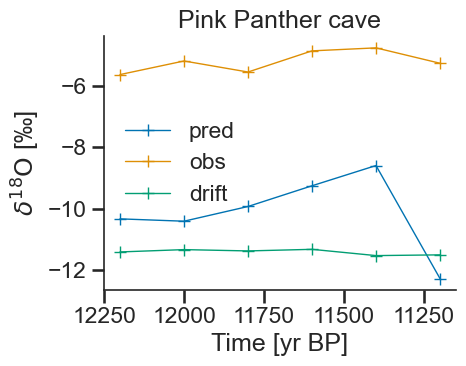

In [8]:
def pot_pred_obs_at_site_over_time(crossval_df, site_name):
    df_site = crossval_df.loc[crossval_df.site_name==site_name]
    fig,ax=plt.subplots(figsize=(5,4))
    plt.plot(df_site.time.values,df_site['z_pred'].values,'-+',linewidth=1.,label='pred')
    plt.plot(df_site.time.values,df_site['z_obs'].values,'-+',linewidth=1.,label='obs')
    plt.plot(df_site.time.values,df_site['drift_at_obs'].values,'-+',linewidth=1.,label='drift')
    plt.xlabel('Time [yr BP]')
    sns.despine()
    ax.invert_xaxis()
    plt.legend(frameon=False)
    plt.ylabel(r'$\delta^{18}\text{O}$ [‰]')
    plt.title(site_name)
    return fig,ax

# explore the sites with the bad PES mean values :
mean_pes = crossval_df.groupby('site_name')[['lon','lat','PES']].mean().reset_index()
print(mean_pes[mean_pes.PES == mean_pes.PES.min()])
min_cave = mean_pes.loc[mean_pes.PES.idxmin(),'site_name']
fig,ax = pot_pred_obs_at_site_over_time(crossval_df,min_cave)
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_DevilsHole.png',dpi=500)
plt.show()

#max
print(mean_pes[mean_pes.PES == mean_pes.PES.max()])
max_cave = mean_pes.loc[mean_pes.PES.idxmax(),'site_name']
fig,ax = pot_pred_obs_at_site_over_time(crossval_df,max_cave)
plt.tight_layout()
plt.show()

#Pacupahuain cave
fig, ax = pot_pred_obs_at_site_over_time(crossval_df,'Pacupahuain cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Pacupahuain.png',dpi=500)
plt.show()

# Kesang cave 
fig,ax = pot_pred_obs_at_site_over_time(crossval_df,'Kesang cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Kesang.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = pot_pred_obs_at_site_over_time(crossval_df,'Sieben Hengste cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_SiebenHengste.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = pot_pred_obs_at_site_over_time(crossval_df,'Pink Panther cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

count    132.000000
mean       0.062594
std        0.812764
min       -2.403574
25%       -0.389103
50%        0.173149
75%        0.620691
max        2.027429
Name: PES, dtype: float64
Cluster: USA, Number of sites: 21


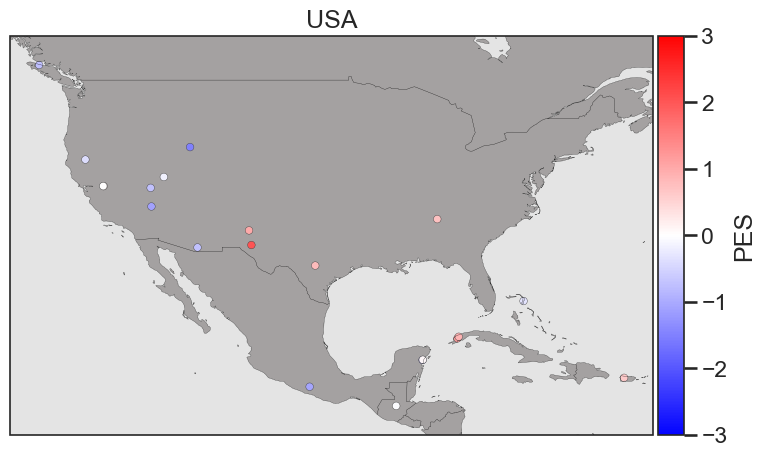

Cluster: Europe, Number of sites: 42


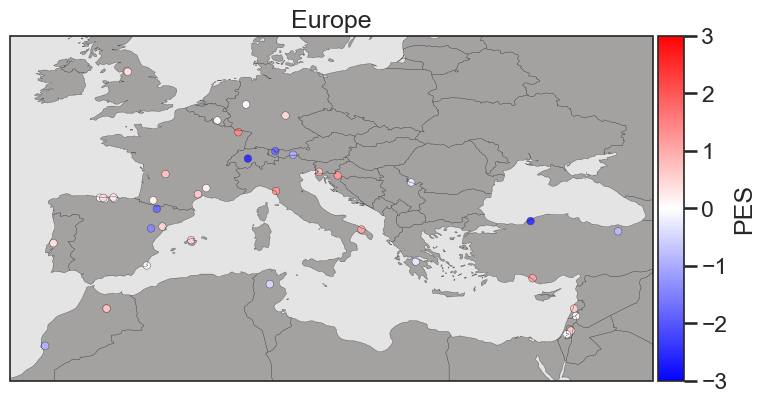

Cluster: Eastern Asia, Number of sites: 34


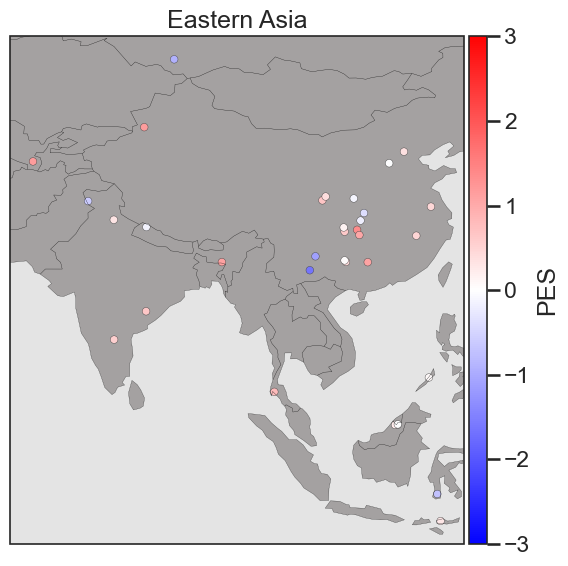

Cluster: Other, Number of sites: 35


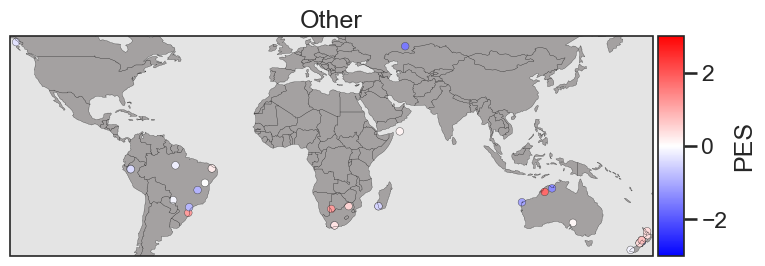

In [85]:
def assign_cluster(row):
    lon, lat = row['lon'], row['lat']
    if -130 < lon < -60 and 15 < lat < 70:  #USA/North America
        return 'USA'
    elif -15 < lon < 50 and 30 < lat < 75:  #Europe and North Maghreb
        return 'Europe'
    elif 60 < lon < 150 and -10 < lat < 55:  #Eastern Asia
        return 'Eastern Asia'
    else:
        return 'Other'

# Add cluster assignment to dataframe
mean_residuals_clustered = crossval_df.groupby('site_name')[['lon','lat','PES']].mean().reset_index()
mean_residuals_clustered['cluster'] = mean_residuals_clustered.apply(assign_cluster, axis=1)
print(mean_residuals_clustered.PES.describe())
clusters = ['USA', 'Europe', 'Eastern Asia', 'Other']
for idx, cluster in enumerate(clusters):
    cluster_data = mean_residuals_clustered[mean_residuals_clustered['cluster'] == cluster]
    print(f"Cluster: {cluster}, Number of sites: {len(cluster_data)}")
    fig_temp, ax_temp = plot_utils.plot_isoscape_latlon_platecarree_df(
        cluster_data,
        time='',
        title=f'{cluster}',
        countries_borders=True,
        qty_col='PES',
        s=30,
        cmap='bwr',
        v_min=-3,
        v_max=3,
        qty_label=r'PES',
        unit=None,
        figsize=(8, 6),
        adjust_extent=True
    )#type:ignore
    plt.tight_layout()
    plt.show()
    plt.close('all')

In the cel below, we investigate whether the statistical was failed in some time slices, and because of which sites.

In [7]:
crossval_df.loc[crossval_df['|PES| > critical_val'],['site_name','dist_nn','z_obs','z_pred','ss_pred','PES','time','lat','lon']]

,site_name,dist_nn,z_obs,z_pred,ss_pred,PES,time,lat,lon
15,Devils Hole,174.634382,-17.817538,-10.990891,4.276028,-3.301317,11600,36.4254,-116.2915
13,Devils Hole,174.634382,-19.506681,-12.450197,4.280788,-3.410567,12400,36.4254,-116.2915
14,Devils Hole,408.576801,-18.465962,-10.902648,5.181874,-3.322528,13800,36.4254,-116.2915
11,Devils Hole,408.576801,-18.569032,-11.242955,5.184717,-3.217429,14200,36.4254,-116.2915
13,Devils Hole,408.576801,-18.476414,-11.242913,5.117588,-3.197539,14400,36.4254,-116.2915
12,Devils Hole,340.261515,-18.870406,-11.970719,4.645868,-3.201076,15000,36.4254,-116.2915
32,Pacupahuain cave,612.441323,-17.716636,-9.468755,6.972527,-3.123542,18400,-11.2400,-75.8200
38,Pacupahuain cave,612.441323,-17.822490,-9.508640,6.973032,-3.148411,18800,-11.2400,-75.8200
31,Pacupahuain cave,612.441323,-17.361342,-8.971806,6.987578,-3.173764,20000,-11.2400,-75.8200


Now, we plot the mean cross-validation residuals at each site for the entire period 20-11ka BP

#### Vizualise kriged dataset

In this section, we open the dataset .nc file that was created by running the script ```kriging.py``` and we plot some isoscapes.

In [2]:
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/speleothems_isoscapes_11_to_20kaBP.nc')

In [3]:
d18Op = kriged_ds.d18Op
d18Op_var = kriged_ds.ss_pred
confidence_flags = kriged_ds.confidence_flag

In [4]:
kriged_ds.time

<xarray.DataArray 'time' (time: 45)> Size: 360B
array([11200., 11400., 11600., 11800., 12000., 12200., 12400., 12600., 12800.,
       13000., 13200., 13400., 13600., 13800., 14000., 14200., 14400., 14600.,
       14800., 15000., 15200., 15400., 15600., 15800., 16000., 16200., 16400.,
       16600., 16800., 17000., 17200., 17400., 17600., 17800., 18000., 18200.,
       18400., 18600., 18800., 19000., 19200., 19400., 19600., 19800., 20000.])
Coordinates:
  * time     (time) float64 360B 1.12e+04 1.14e+04 1.16e+04 ... 1.98e+04 2e+04
Attributes:
    units:        years
    description:  Years before Present (1950). Positive integers.

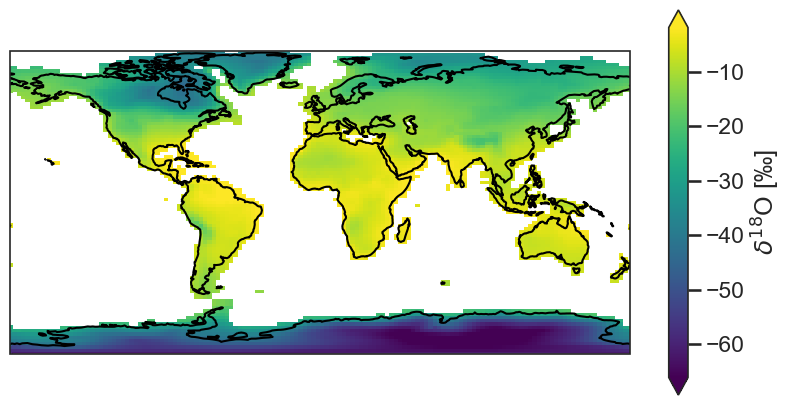

In [5]:
fig = plot_utils.plot_isoscape_latlon_platecarree(d18Op.sel(time=19200),time='',title='')
plt.show()

In [6]:
kriged_df = kriged_ds.to_dataframe().reset_index().dropna()

In [7]:
kriged_df.columns

Index(['time', 'lat', 'lon', 'd18Op', 'ss_pred', 'confidence_flag'], dtype='object')

In [9]:
kriged_df['std']=np.sqrt(kriged_df.ss_pred)

=== 12 ka BP ===
itrace_df ready
-33.063114166259766 -1.4799237251281738


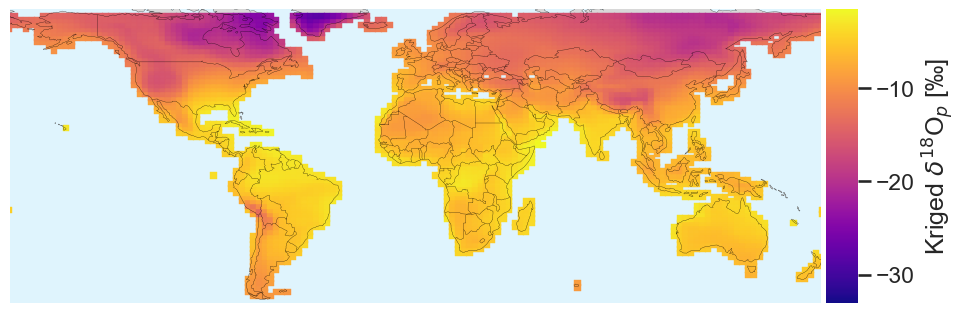

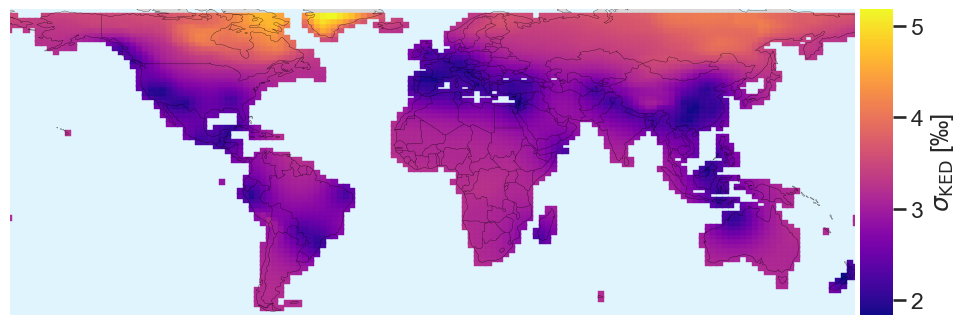

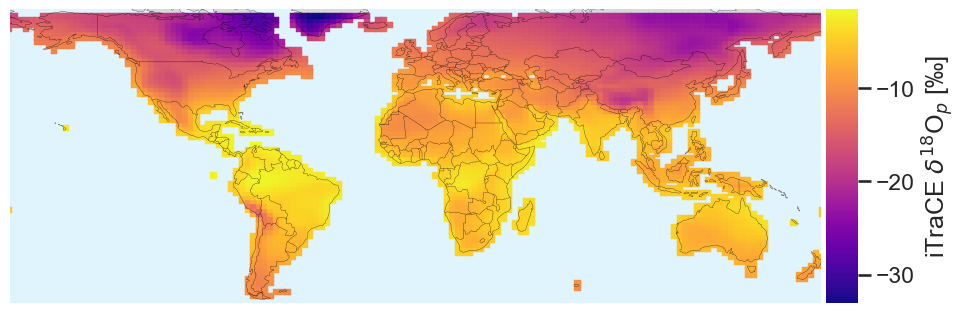

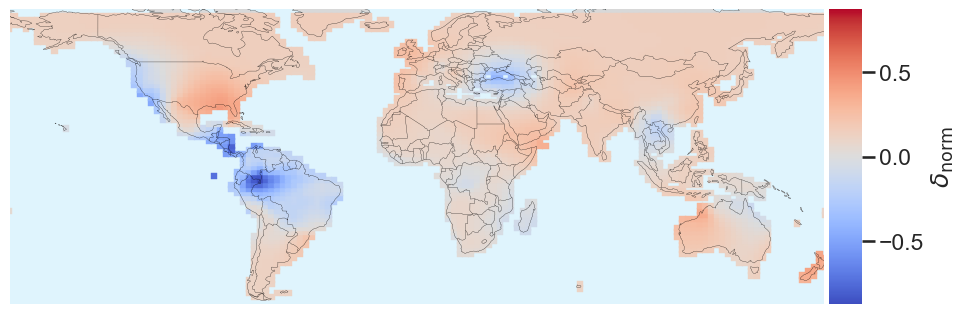

In [19]:
# compare to itrace values

# load itrace siulations dict 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sims = dict((k,itrace_sims[k]) for k in ('12', # early holocene
                                        #  '13',
                                        #  '14',
                                        #  '15', # HS1
                                        #  '16',
                                        #  '17',
                                        #  '18',
                                        #  '19',
                                        #  '20' # last millenial of LGM
                                         ) if k in itrace_sims)

for kyr,dict_ in sims.items() :
    print(f'=== {kyr} ka BP ===')
    itrace_df  = geostat_utils.get_preprocessed_itrace_data(
            res=200*12, # 200 years times 12 months
            data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
            format='df',
            verbose=False,
            sim_suffix =dict_['suffix'], 
            sim_forcings=dict_['forcings'],
            sim_kyr= int(dict_['yrBPname']),
            sim_num=dict_['num'],
            sim_model='clm2.h0',
        ) # df
    if any(itrace_df.lon > 180): itrace_df['lon'] =  utils.convert_lon_0_360_to_neg180_180(itrace_df.lon.values) #type:ignore
    itrace_df['ageyrBP']= utils.get_yrBP_from_itrace_time(itrace_df.time.values,start_year=int(kyr)*1000)#type:ignore
    
    # keep only the 200-year slice at the beginning of this 1000 years slice 
    itrace_slice = itrace_df[(itrace_df.ageyrBP == int(kyr)*1000)&(itrace_df.lat.between(-55,70))].copy() #type:ignore
    kriged_slice = kriged_df[(kriged_df.time == int(kyr)*1000)&(kriged_df.lat.between(-55,70))].copy() 

    # set a single colorbar for both next plots 
    vmin = min(min(itrace_slice.d18Op),min(kriged_slice.d18Op))
    vmax = max(max(itrace_slice.d18Op),max(kriged_slice.d18Op))
    print(vmin,vmax)
    fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
                df=kriged_slice,
                title=None,
                v_min=vmin,
                v_max=vmax,
                cmap='plasma',
                qty_label=r'Kriged $\delta^{18}$O$_p$',
                countries_borders=True) #type:ignore
    plt.tight_layout()
    # plt.savefig(f'../output/results_figs/kriged_isoscape_{kyr}_kaBP.png',dpi=500)
    plt.show()
    fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
                df=kriged_slice,
                title=None,
                qty_col = 'std',
                # v_min=vmin,
                # v_max=vmax,
                cmap='plasma',
                qty_label=r'$\sigma_\text{KED}$',
                unit=r'‰',
                countries_borders=True) #type:ignore
    plt.tight_layout()
    plt.savefig(f'../output/results_figs/kriged_isoscape_std_{kyr}_kaBP.png',dpi=500)
    plt.show()
    fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
        itrace_slice,#type:ignore
        v_min=vmin,
        v_max=vmax,
        cmap='plasma',
        qty_label=r'iTraCE $\delta^{18}$O$_p$',
        title=None,
        countries_borders=True
    )
    plt.tight_layout()
    # plt.savefig(f'../output/results_figs/itrace_isoscape_{kyr}_kaBP.png',dpi=500)
    plt.show()

    # compute the difference at each location 
    itrace_slice = itrace_slice.rename(columns={'d18Op':'itrace_d18Op'})
    kriged_slice = kriged_slice.rename(columns= {'d18Op':'kriged_d18Op'})

    merged_df = pd.merge(left=kriged_slice[['lat','lon','kriged_d18Op']],right=itrace_slice[['lat','lon','itrace_d18Op']],how='outer',on=['lat','lon']) #type:ignore

    merged_df['diff'] = (merged_df.kriged_d18Op - merged_df.itrace_d18Op)/np.abs(merged_df.itrace_d18Op)
    merged_df.dropna(subset='diff')

    fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
        merged_df,#type:ignore
        qty_col='diff',
        qty_label=r'$\delta_\text{norm}$',
        cmap='coolwarm',
        cmap_sym0=True,
        title=None,
        unit=None,
        countries_borders=True
    )
    plt.tight_layout()
    plt.savefig(f'../output/results_figs/kriged_isoscape_norm_diff_{kyr}_kaBP.png',dpi=500)
    plt.show()